# Classificacao da Qualidade de Vinhos com KNN
## Trabalho Interdisciplinar - UniEduK
**Disciplinas:** Matematica para Computacao | IA e suas Aplicacoes | Fundamentos de Programacao | Fundamentos de Logica

---

## 1. Importacao das Bibliotecas

Importamos todas as bibliotecas necessarias para o projeto:
- **pandas / numpy**: manipulacao e operacoes numericas nos dados
- **matplotlib / seaborn**: geracao dos graficos da analise exploratoria
- **sklearn**: implementacao do KNN com biblioteca pronta (etapa 3) e metricas de avaliacao
- **math / collections**: usadas na implementacao *manual* do KNN (etapa 2), sem bibliotecas prontas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from collections import Counter

# Sklearn - usado APENAS na etapa de implementacao com biblioteca
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100
print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


## 2. Carregamento e Visao Geral do Dataset

O dataset utilizado e o **Wine Quality Dataset**, que contem informacoes fisico-quimicas de vinhos tintos e brancos portugueses da regiao do Minho. O objetivo e **classificar a qualidade do vinho** (variavel `quality`) com base em 11 atributos numericos.

**Fonte:** UCI Machine Learning Repository - P. Cortez et al. (2009)

O dataset possui 6497 amostras e 13 colunas (11 atributos quimicos + quality + type). A variavel alvo e `quality`, com notas de 3 a 9 atribuidas por especialistas.

In [2]:
# Carrega o CSV com os dados brutos
df = pd.read_csv("wine_quality_dataset.csv")

print(f"Shape do dataset: {df.shape[0]} linhas x {df.shape[1]} colunas")
print(f"\nColunas: {list(df.columns)}")
print(f"\nTipos de vinho: {df['type'].value_counts().to_dict()}")
print(f"\nDistribuicao da variavel alvo (quality):")
print(df['quality'].value_counts().sort_index())
df.head()

Shape do dataset: 6497 linhas x 13 colunas

Colunas: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'type']

Tipos de vinho: {'white': 4898, 'red': 1599}

Distribuicao da variavel alvo (quality):
quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


## 3. Analise Exploratoria dos Dados (EDA)

Antes de treinar qualquer modelo, e essencial entender a distribuicao e as caracteristicas do dataset. Essa etapa identifica problemas como valores ausentes, outliers e desbalanceamento de classes, que podem impactar o desempenho do algoritmo.

In [3]:
# Estatisticas descritivas de todas as variaveis numericas
print("=== Estatisticas Descritivas ===")
df.describe().round(3)

=== Estatisticas Descritivas ===


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000
mean,7.215,0.340,0.319,5.443,0.056,30.525,115.745,0.995,3.219,0.531,10.492,5.818
std,1.296,0.165,0.145,4.758,0.035,17.749,56.522,0.003,0.161,0.149,1.193,0.873
min,3.800,0.080,0.000,0.600,0.009,1.000,6.000,0.987,2.720,0.220,8.000,3.000
25%,6.400,0.230,0.250,1.800,0.038,17.000,77.000,0.992,3.110,0.430,9.500,5.000
50%,7.000,0.290,0.310,3.000,0.047,29.000,118.000,0.995,3.210,0.510,10.300,6.000
75%,7.700,0.400,0.390,8.100,0.065,41.000,156.000,0.997,3.320,0.600,11.300,6.000
max,15.900,1.580,1.660,65.800,0.611,289.000,440.000,1.039,4.010,2.000,14.900,9.000


In [4]:
# Verificacao de valores ausentes - importante antes de qualquer modelagem
print("=== Valores Ausentes por Coluna ===")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("Nenhum valor ausente encontrado no dataset!")
else:
    print(missing[missing > 0])

=== Valores Ausentes por Coluna ===
Nenhum valor ausente encontrado no dataset!


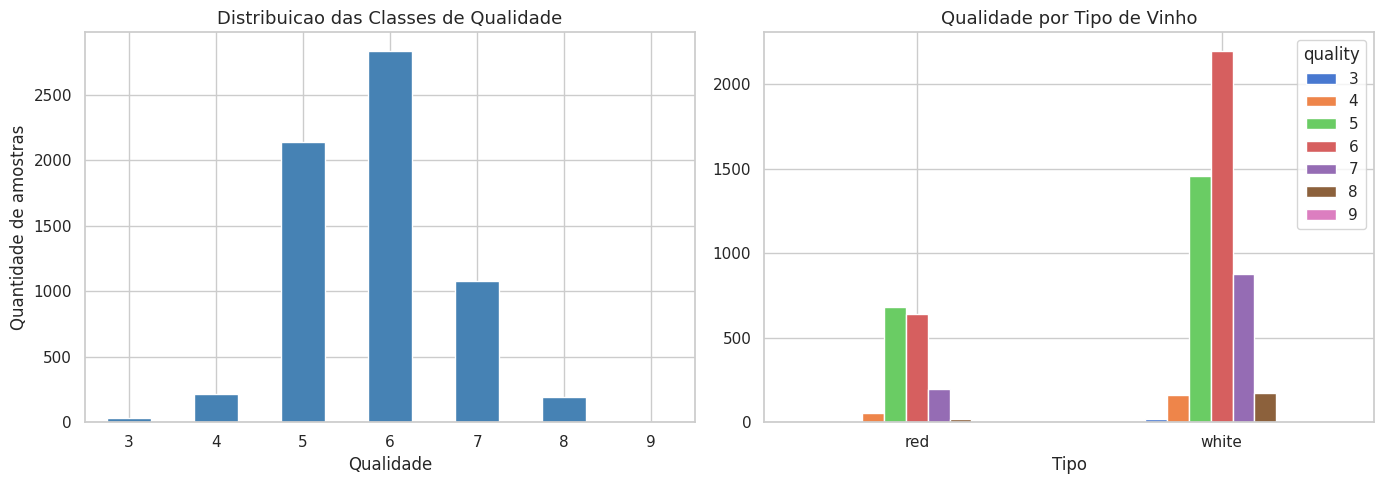

Observacao: as classes 5 e 6 dominam o dataset - ha desbalanceamento.


In [5]:
# Distribuicao da variavel alvo - visualizamos o balanceamento das classes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['quality'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribuicao das Classes de Qualidade', fontsize=13)
axes[0].set_xlabel('Qualidade')
axes[0].set_ylabel('Quantidade de amostras')
axes[0].tick_params(axis='x', rotation=0)

df.groupby(['type', 'quality']).size().unstack().plot(
    kind='bar', ax=axes[1], edgecolor='white')
axes[1].set_title('Qualidade por Tipo de Vinho', fontsize=13)
axes[1].set_xlabel('Tipo')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig("distribuicao_qualidade.png", bbox_inches='tight')
plt.show()
print("Observacao: as classes 5 e 6 dominam o dataset - ha desbalanceamento.")

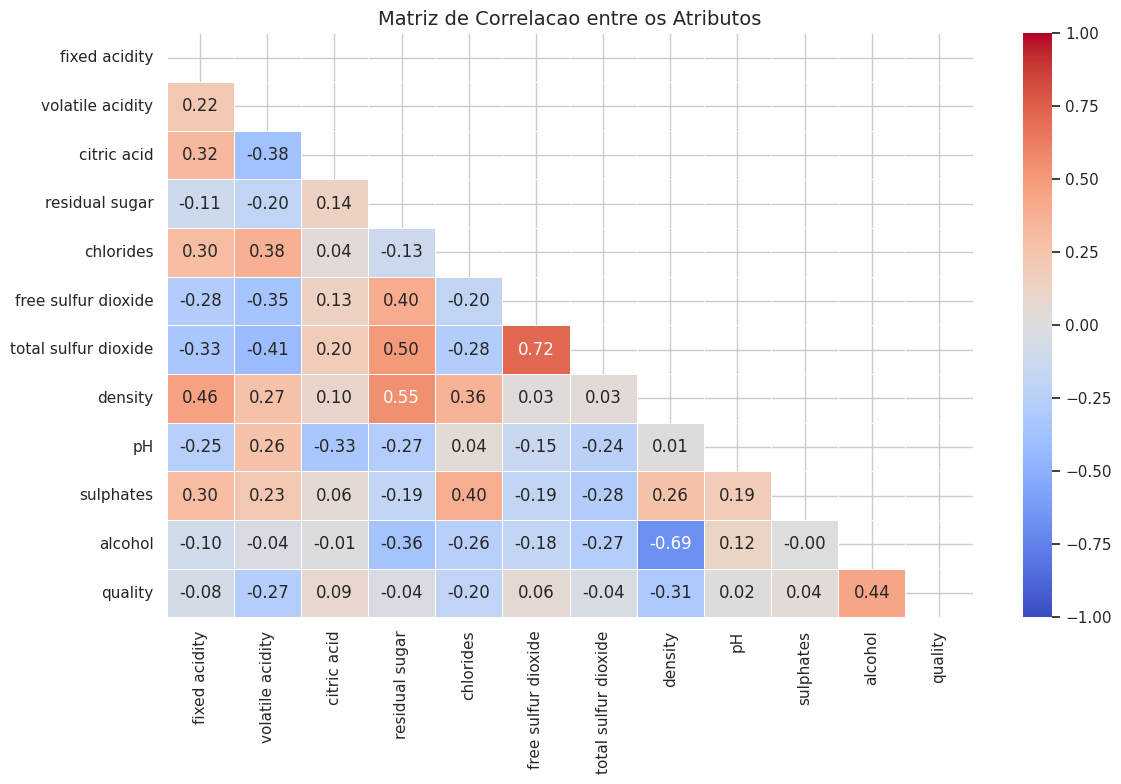

'alcohol' tem correlacao positiva com 'quality' (~0.44).
'volatile acidity' tem correlacao negativa com 'quality' (~-0.27).


In [6]:
# Heatmap de correlacao entre atributos
# Ajuda a identificar quais variaveis tem maior relacao com a qualidade
fig, ax = plt.subplots(figsize=(12, 8))
corr = df.drop(columns=['type']).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            ax=ax, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title("Matriz de Correlacao entre os Atributos", fontsize=14)
plt.tight_layout()
plt.savefig("correlacao.png", bbox_inches='tight')
plt.show()
print("'alcohol' tem correlacao positiva com 'quality' (~0.44).")
print("'volatile acidity' tem correlacao negativa com 'quality' (~-0.27).")

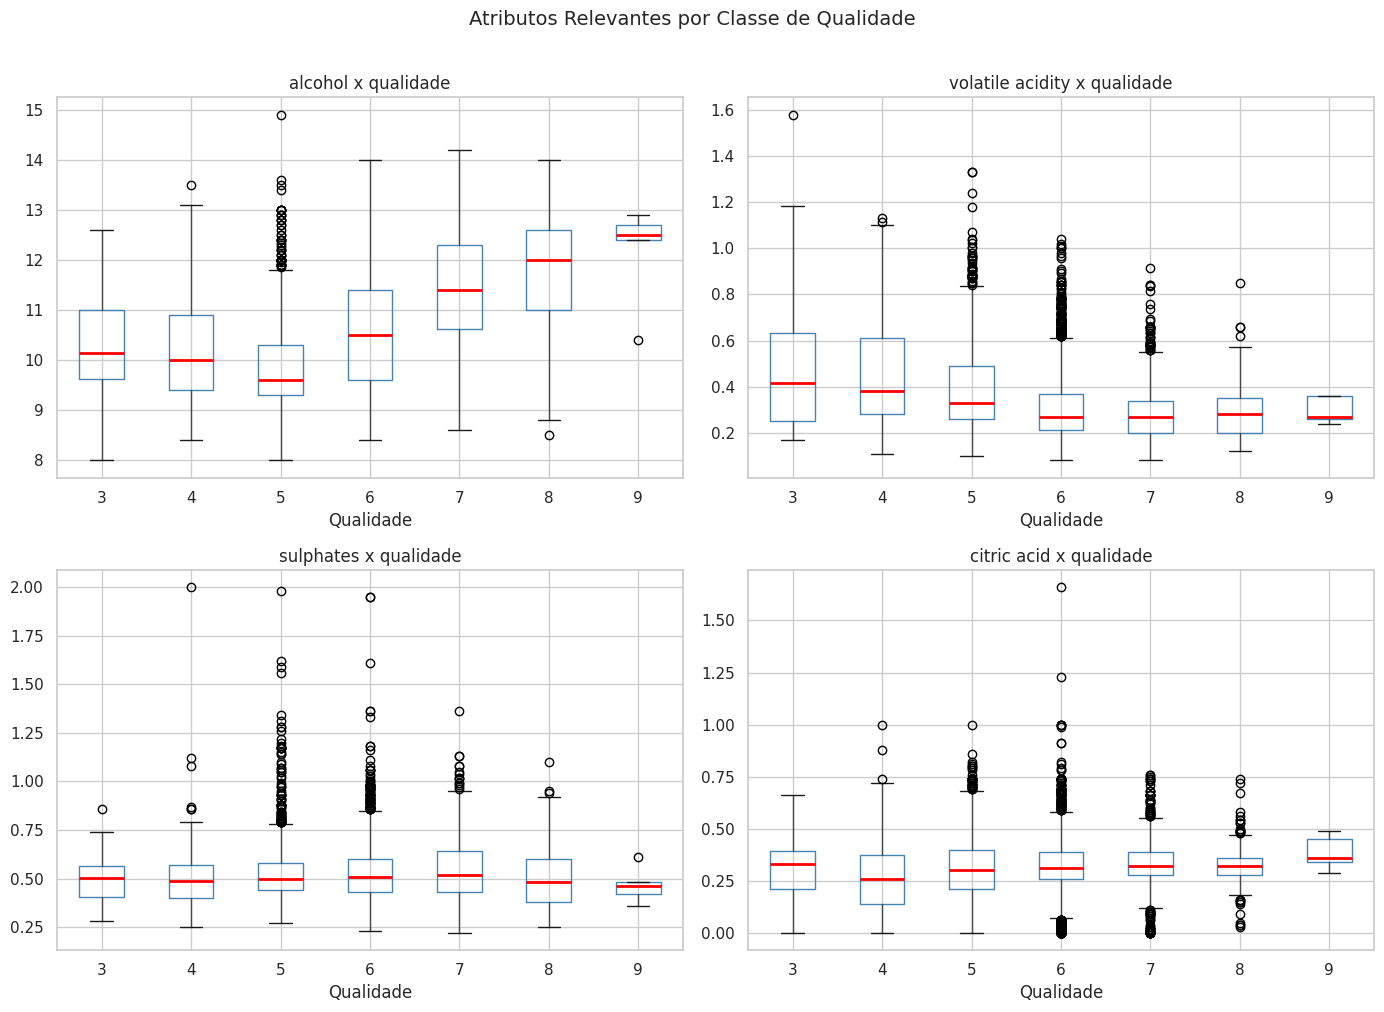

In [7]:
# Boxplots dos atributos mais relevantes vs qualidade
# Permite visualizar como cada atributo varia entre as classes de qualidade
features_relevantes = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(features_relevantes):
    df.boxplot(column=feat, by='quality', ax=axes[i],
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(feat + ' x qualidade')
    axes[i].set_xlabel('Qualidade')

plt.suptitle('Atributos Relevantes por Classe de Qualidade', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("boxplots.png", bbox_inches='tight')
plt.show()

## 4. Pre-processamento dos Dados

O pre-processamento e a etapa em que preparamos o dataset para que o algoritmo KNN funcione corretamente. O KNN e sensivel a escala dos dados, pois usa distancia Euclidiana - atributos com valores muito maiores dominam o calculo se nao forem normalizados.

**Decisoes tomadas:**
1. Remover a coluna `type` (texto categorico)
2. Criar **classificacao binaria**: qualidade >= 7 = 'boa' (1), caso contrario = 'ruim' (0)
3. **Normalizar (Z-score)** todos os atributos para media 0 e desvio padrao 1
4. Dividir em **treino (80%)** e **teste (20%)** com seed fixo para reproducibilidade

In [8]:
# Passo 1: remover coluna categorica 'type' (texto - nao numerico)
# O KNN trabalha com distancias numericas, entao colunas de texto precisam ser
# removidas ou convertidas. Optamos por remover para simplificar a implementacao manual.
df_proc = df.drop(columns=['type']).copy()

# Passo 2: binarizar a variavel alvo
# Qualidade >= 7 --> "boa" (1) | Qualidade < 7 --> "ruim" (0)
# Essa decisao simplifica o problema multiclasse para binario,
# tornando mais facil avaliar e interpretar os resultados.
df_proc['qualidade_binaria'] = (df_proc['quality'] >= 7).astype(int)
df_proc = df_proc.drop(columns=['quality'])

print("=== Distribuicao das classes binarias ===")
contagem = df_proc['qualidade_binaria'].value_counts()
print(f"  Ruim (0 - quality < 7):  {contagem[0]} amostras ({contagem[0]/len(df_proc)*100:.1f}%)")
print(f"  Boa  (1 - quality >= 7): {contagem[1]} amostras ({contagem[1]/len(df_proc)*100:.1f}%)")
df_proc.head()

=== Distribuicao das classes binarias ===
  Ruim (0 - quality < 7):  5220 amostras (80.3%)
  Boa  (1 - quality >= 7): 1277 amostras (19.7%)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,qualidade_binaria
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0


In [9]:
# Passo 3: separar features (X) e alvo (y)
# X: matriz com todos os atributos preditores (entrada do modelo)
# y: vetor com as classes reais (saida esperada)
X = df_proc.drop(columns=['qualidade_binaria']).values   # matriz numpy
y = df_proc['qualidade_binaria'].values                  # vetor numpy

feature_names = list(df_proc.drop(columns=['qualidade_binaria']).columns)
print(f"Features utilizadas ({len(feature_names)}): {feature_names}")
print(f"Shape de X: {X.shape} | Shape de y: {y.shape}")

Features utilizadas (11): ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
Shape de X: (6497, 11) | Shape de y: (6497,)


In [10]:
# Passo 4: divisao treino/teste (80% / 20%)
# O seed fixo (42) garante reproducibilidade - mesma divisao em toda execucao.
np.random.seed(42)
indices = np.random.permutation(len(X))
split   = int(0.8 * len(X))

X_train_raw, X_test_raw = X[indices[:split]], X[indices[split:]]
y_train,      y_test     = y[indices[:split]], y[indices[split:]]

print(f"Treino: {len(X_train_raw)} amostras | Teste: {len(X_test_raw)} amostras")

Treino: 5197 amostras | Teste: 1300 amostras


In [11]:
# Passo 5: normalizacao Z-score
# Formula: x_normalizado = (x - media) / desvio_padrao
# Calculamos media e desvio APENAS no treino para evitar data leakage
# (vazamento de informacao do teste para o treino, o que inflaria a acuracia).
media  = X_train_raw.mean(axis=0)
desvio = X_train_raw.std(axis=0)

X_train = (X_train_raw - media) / desvio   # normaliza treino
X_test  = (X_test_raw  - media) / desvio   # aplica mesma escala no teste

print("=== Verificacao apos normalizacao (conjunto de treino) ===")
for i, feat in enumerate(feature_names):
    print(f"  {feat:25s}  media={X_train[:,i].mean():+.4f}  desvio={X_train[:,i].std():.4f}")

=== Verificacao apos normalizacao (conjunto de treino) ===
  fixed acidity              media=-0.0000  desvio=1.0000
  volatile acidity           media=-0.0000  desvio=1.0000
  citric acid                media=+0.0000  desvio=1.0000
  residual sugar             media=-0.0000  desvio=1.0000
  chlorides                  media=-0.0000  desvio=1.0000
  free sulfur dioxide        media=-0.0000  desvio=1.0000
  total sulfur dioxide       media=+0.0000  desvio=1.0000
  density                    media=+0.0000  desvio=1.0000
  pH                         media=+0.0000  desvio=1.0000
  sulphates                  media=-0.0000  desvio=1.0000
  alcohol                    media=-0.0000  desvio=1.0000


In [12]:
# Salvar dados filtrados/preparados em CSV (Entregavel 2 - item 4)
df_filtrado_full = pd.DataFrame(
    np.hstack([X, y.reshape(-1,1)]),
    columns=feature_names + ['qualidade_binaria']
)
df_filtrado_full.to_csv("wine_quality_filtrado.csv", index=False)
print("Arquivo 'wine_quality_filtrado.csv' salvo com os dados preparados!")
df_filtrado_full.head()

Arquivo 'wine_quality_filtrado.csv' salvo com os dados preparados!


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,qualidade_binaria
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0.0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0.0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0.0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,0.0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0.0


## 5. Implementacao Manual do KNN (sem bibliotecas prontas)

O algoritmo KNN (K-Nearest Neighbors) classifica uma nova amostra com base nas **K amostras de treino mais proximas**, usando a **Distancia Euclidiana** como metrica.

### Distancia Euclidiana entre dois pontos A e B com n dimensoes:

$$d(A, B) = \\sqrt{\\sum_{i=1}^{n}(a_i - b_i)^2}$$

### Passos do algoritmo:
1. Para cada ponto de teste, calcular a distancia ate **todos** os pontos de treino
2. Selecionar os **K vizinhos mais proximos** (menores distancias)
3. Fazer **votacao majoritaria** entre as classes dos K vizinhos
4. Atribuir a classe vencedora ao ponto de teste

### Estruturas de programacao utilizadas:
- **Variaveis numericas**: distancia, indices, acuracia
- **Listas**: armazenar distancias e classes dos vizinhos
- **Estruturas de repeticao (for)**: percorrer pontos de treino e de teste
- **Estruturas condicionais (if)**: verificar acertos
- **Funcoes**: modularizacao do codigo em blocos reutilizaveis

In [13]:
# ============================================================
# IMPLEMENTACAO MANUAL DO KNN - sem uso de sklearn ou similares
# ============================================================

def distancia_euclidiana(ponto_a, ponto_b):
    '''
    Calcula a Distancia Euclidiana entre dois vetores n-dimensionais.
    Formula: sqrt( soma( (a_i - b_i)^2 ) )

    Esta funcao usa apenas operacoes basicas de Python (soma, subtracao,
    multiplicacao e raiz quadrada via math.sqrt), sem numpy ou sklearn.

    Parametros:
        ponto_a : lista de numeros (coordenadas do ponto A)
        ponto_b : lista de numeros (coordenadas do ponto B)
    Retorna:
        float - distancia euclidiana entre os dois pontos
    '''
    soma_quadrados = 0.0   # variavel numerica acumuladora

    # Estrutura de repeticao: percorre cada dimensao dos dois pontos
    for a, b in zip(ponto_a, ponto_b):
        soma_quadrados += (a - b) ** 2   # calcula (a_i - b_i)^2 e acumula

    return math.sqrt(soma_quadrados)     # raiz quadrada da soma total


def knn_manual(X_treino, y_treino, X_novo, k):
    '''
    Classifica um unico ponto usando KNN implementado do zero.

    Parametros:
        X_treino : lista de listas com os atributos de treino
        y_treino : lista com as classes de treino
        X_novo   : lista com os atributos do ponto a classificar
        k        : numero de vizinhos (hiperparametro)
    Retorna:
        int - classe prevista (0 ou 1) por votacao majoritaria
    '''
    # Lista para guardar pares (distancia, classe) de cada ponto de treino
    distancias = []

    # Estrutura de repeticao: percorre todos os pontos do conjunto de treino
    for i in range(len(X_treino)):
        dist = distancia_euclidiana(X_novo, X_treino[i])   # calcula distancia
        distancias.append((dist, y_treino[i]))              # guarda na lista

    # Ordena a lista pelo primeiro elemento da tupla (distancia) - crescente
    distancias.sort(key=lambda tupla: tupla[0])

    # Seleciona apenas os K primeiros (menores distancias = vizinhos mais proximos)
    k_vizinhos = distancias[:k]

    # Extrai somente as classes dos K vizinhos (descarta as distancias)
    classes_vizinhos = [classe for _, classe in k_vizinhos]

    # Votacao majoritaria: Counter conta ocorrencias de cada classe
    contagem_votos = Counter(classes_vizinhos)
    classe_prevista = contagem_votos.most_common(1)[0][0]

    return classe_prevista


def knn_prever_conjunto(X_treino, y_treino, X_teste, k):
    '''
    Aplica knn_manual para cada ponto do conjunto de teste.
    Estrutura de repeticao (for) percorre todos os pontos e acumula previsoes.

    Retorna:
        lista com todas as classes previstas
    '''
    previsoes = []   # lista que armazenara as predicoes

    for ponto in X_teste:        # repete para cada ponto de teste
        pred = knn_manual(X_treino, y_treino, ponto, k)
        previsoes.append(pred)   # adiciona previsao a lista

    return previsoes

print("Funcoes do KNN manual definidas com sucesso!")
print("  - distancia_euclidiana(ponto_a, ponto_b)")
print("  - knn_manual(X_treino, y_treino, X_novo, k)")
print("  - knn_prever_conjunto(X_treino, y_treino, X_teste, k)")

Funcoes do KNN manual definidas com sucesso!
  - distancia_euclidiana(ponto_a, ponto_b)
  - knn_manual(X_treino, y_treino, X_novo, k)
  - knn_prever_conjunto(X_treino, y_treino, X_teste, k)


In [14]:
# Execucao do KNN Manual com K=5
# Usamos uma amostra menor por limitacao de desempenho:
# o KNN manual e O(n*m) sem otimizacoes internas (mais lento para datasets grandes).

AMOSTRA = 500
np.random.seed(42)
idx_amostra = np.random.choice(len(X_train), AMOSTRA, replace=False)

# Convertemos para listas Python pois nossa implementacao nao usa numpy
X_train_manual = X_train[idx_amostra].tolist()
y_train_manual = y_train[idx_amostra].tolist()
X_test_manual  = X_test[:200].tolist()
y_test_manual  = y_test[:200].tolist()

print(f"Executando KNN Manual com K=5...")
print(f"  Treino: {len(X_train_manual)} amostras | Teste: {len(X_test_manual)} amostras")

K = 5
previsoes_k5 = knn_prever_conjunto(X_train_manual, y_train_manual, X_test_manual, K)

# Calculo manual da acuracia - sem sklearn.metrics
acertos = 0
for real, pred in zip(y_test_manual, previsoes_k5):
    if real == pred:   # estrutura condicional: verifica se acertou
        acertos += 1

acuracia_manual_k5 = acertos / len(y_test_manual)

print(f"\nKNN Manual finalizado!")
print(f"  Acertos: {acertos}/{len(y_test_manual)}")
print(f"  Acuracia com K={K}: {acuracia_manual_k5:.4f} ({acuracia_manual_k5*100:.2f}%)")

Executando KNN Manual com K=5...
  Treino: 500 amostras | Teste: 200 amostras



KNN Manual finalizado!
  Acertos: 150/200
  Acuracia com K=5: 0.7500 (75.00%)


In [15]:
# Teste com diferentes valores de K (implementacao manual)
# Objetivo: encontrar o K otimo testando multiplos valores
print("Testando diferentes valores de K no KNN Manual...")
valores_k = [1, 3, 5, 7, 9, 11]
resultados_manual = {}

for k_val in valores_k:
    preds = knn_prever_conjunto(X_train_manual, y_train_manual, X_test_manual, k_val)
    acertos = sum(1 for r, p in zip(y_test_manual, preds) if r == p)
    acc = acertos / len(y_test_manual)
    resultados_manual[k_val] = acc
    print(f"  K={k_val:2d}  -->  Acuracia: {acc:.4f} ({acc*100:.2f}%)")

melhor_k_manual = max(resultados_manual, key=resultados_manual.get)
print(f"\nMelhor K (manual): {melhor_k_manual} com acuracia de {resultados_manual[melhor_k_manual]*100:.2f}%")

Testando diferentes valores de K no KNN Manual...


  K= 1  -->  Acuracia: 0.7600 (76.00%)


  K= 3  -->  Acuracia: 0.7550 (75.50%)


  K= 5  -->  Acuracia: 0.7500 (75.00%)


  K= 7  -->  Acuracia: 0.7300 (73.00%)


  K= 9  -->  Acuracia: 0.7450 (74.50%)


  K=11  -->  Acuracia: 0.7400 (74.00%)

Melhor K (manual): 1 com acuracia de 76.00%


## 6. Implementacao do KNN com Biblioteca (scikit-learn)

Agora utilizamos o `KNeighborsClassifier` do **scikit-learn**, que e altamente otimizado (usa estruturas como KD-Tree internamente) e permite trabalhar com **todo o dataset** de forma eficiente. Comparamos com nossa implementacao manual para validar os resultados.

In [16]:
# Normalizacao com StandardScaler do sklearn (equivalente ao que fizemos manualmente)
# O scaler e treinado apenas no conjunto de treino para evitar data leakage
scaler     = StandardScaler()
X_train_sk = scaler.fit_transform(X_train_raw)
X_test_sk  = scaler.transform(X_test_raw)

print("Normalizacao com StandardScaler concluida!")
print(f"  Treino: {X_train_sk.shape} | Teste: {X_test_sk.shape}")

Normalizacao com StandardScaler concluida!
  Treino: (5197, 11) | Teste: (1300, 11)


In [17]:
# Teste com diferentes valores de K usando sklearn (dataset completo)
print("Testando KNN com sklearn em diferentes valores de K...")

valores_k_sk = [1, 3, 5, 7, 9, 11, 15, 21]
resultados_sklearn = {}

for k_val in valores_k_sk:
    knn_sk = KNeighborsClassifier(n_neighbors=k_val, metric='euclidean')
    knn_sk.fit(X_train_sk, y_train)       # treina o modelo
    preds  = knn_sk.predict(X_test_sk)    # faz predicoes
    acc    = accuracy_score(y_test, preds) # avalia acuracia
    resultados_sklearn[k_val] = acc
    print(f"  K={k_val:2d}  -->  Acuracia: {acc:.4f} ({acc*100:.2f}%)")

melhor_k_sk = max(resultados_sklearn, key=resultados_sklearn.get)
print(f"\nMelhor K (sklearn): {melhor_k_sk} com acuracia de {resultados_sklearn[melhor_k_sk]*100:.2f}%")

Testando KNN com sklearn em diferentes valores de K...
  K= 1  -->  Acuracia: 0.8615 (86.15%)


  K= 3  -->  Acuracia: 0.8431 (84.31%)
  K= 5  -->  Acuracia: 0.8454 (84.54%)
  K= 7  -->  Acuracia: 0.8385 (83.85%)


  K= 9  -->  Acuracia: 0.8415 (84.15%)


  K=11  -->  Acuracia: 0.8408 (84.08%)
  K=15  -->  Acuracia: 0.8362 (83.62%)
  K=21  -->  Acuracia: 0.8423 (84.23%)

Melhor K (sklearn): 1 com acuracia de 86.15%


In [18]:
# Relatorio completo de classificacao com o melhor K encontrado
knn_final    = KNeighborsClassifier(n_neighbors=melhor_k_sk, metric='euclidean')
knn_final.fit(X_train_sk, y_train)
y_pred_final = knn_final.predict(X_test_sk)

print(f"=== Relatorio de Classificacao (K={melhor_k_sk}) ===\n")
print(classification_report(y_test, y_pred_final,
      target_names=['Ruim (quality < 7)', 'Boa (quality >= 7)']))

=== Relatorio de Classificacao (K=1) ===

                    precision    recall  f1-score   support

Ruim (quality < 7)       0.93      0.90      0.91      1051
Boa (quality >= 7)       0.62      0.71      0.66       249

          accuracy                           0.86      1300
         macro avg       0.78      0.80      0.79      1300
      weighted avg       0.87      0.86      0.86      1300



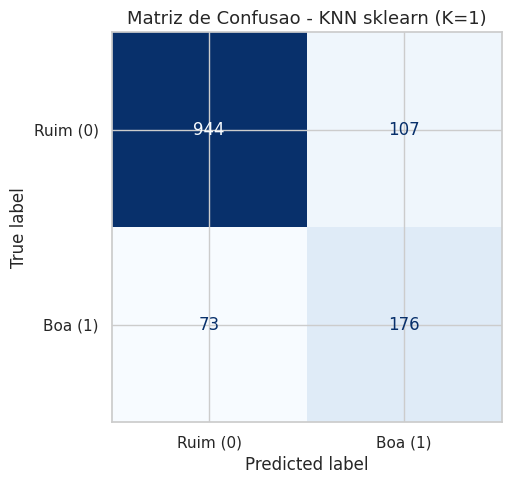


Interpretacao da Matriz de Confusao:
  Verdadeiros Negativos (Ruim previsto Ruim): 944
  Falsos Positivos (Ruim previsto Boa)      : 107
  Falsos Negativos (Boa previsto Ruim)      : 73
  Verdadeiros Positivos (Boa previsto Boa)  : 176


In [19]:
# Matriz de confusao - visualiza os acertos e erros do modelo
fig, ax = plt.subplots(figsize=(7, 5))
cm   = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Ruim (0)', 'Boa (1)'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Matriz de Confusao - KNN sklearn (K={melhor_k_sk})', fontsize=13)
plt.tight_layout()
plt.savefig("matriz_confusao.png", bbox_inches='tight')
plt.show()

print("\nInterpretacao da Matriz de Confusao:")
print(f"  Verdadeiros Negativos (Ruim previsto Ruim): {cm[0][0]}")
print(f"  Falsos Positivos (Ruim previsto Boa)      : {cm[0][1]}")
print(f"  Falsos Negativos (Boa previsto Ruim)      : {cm[1][0]}")
print(f"  Verdadeiros Positivos (Boa previsto Boa)  : {cm[1][1]}")

## 7. Comparacao dos Resultados: KNN Manual x KNN sklearn

Nesta etapa comparamos as duas abordagens considerando:
- **Facilidade de implementacao**: complexidade do codigo, linhas necessarias, clareza
- **Diferencas nos resultados**: acuracia, volume de dados processado, velocidade

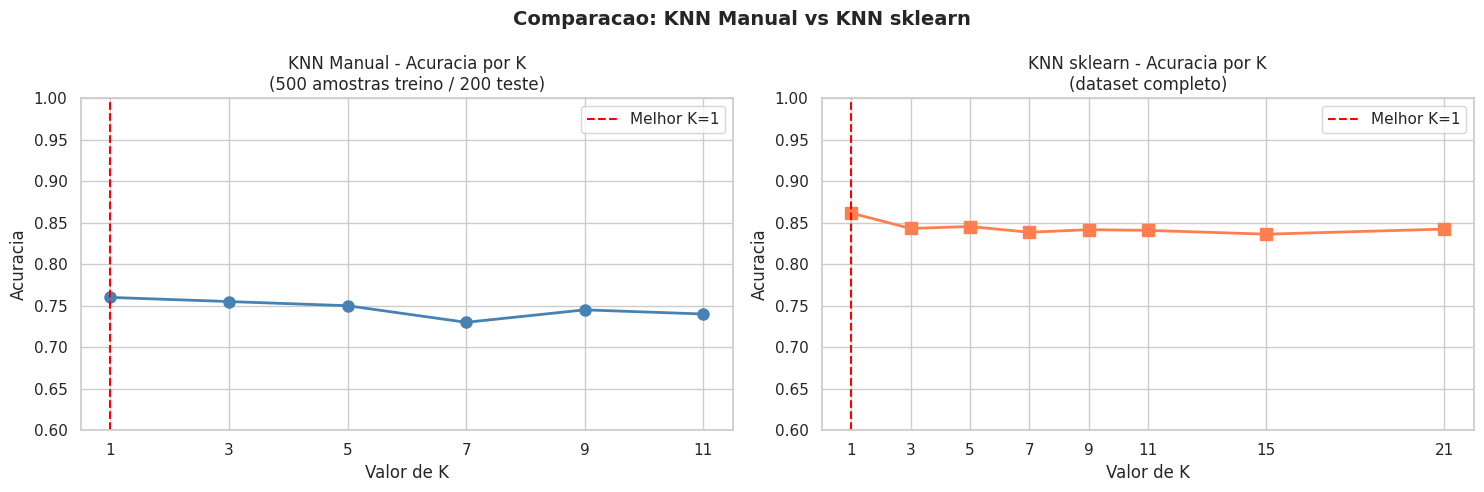

In [20]:
# Grafico comparativo de acuracia por K (as duas abordagens)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

k_vals_m   = list(resultados_manual.keys())
acc_vals_m = [resultados_manual[k] for k in k_vals_m]
axes[0].plot(k_vals_m, acc_vals_m, 'o-', color='steelblue', linewidth=2, markersize=8)
axes[0].set_title('KNN Manual - Acuracia por K\n(500 amostras treino / 200 teste)', fontsize=12)
axes[0].set_xlabel('Valor de K')
axes[0].set_ylabel('Acuracia')
axes[0].set_xticks(k_vals_m)
axes[0].axvline(x=melhor_k_manual, color='red', linestyle='--', label=f'Melhor K={melhor_k_manual}')
axes[0].legend()
axes[0].set_ylim(0.6, 1.0)

k_vals_sk   = list(resultados_sklearn.keys())
acc_vals_sk = [resultados_sklearn[k] for k in k_vals_sk]
axes[1].plot(k_vals_sk, acc_vals_sk, 's-', color='coral', linewidth=2, markersize=8)
axes[1].set_title('KNN sklearn - Acuracia por K\n(dataset completo)', fontsize=12)
axes[1].set_xlabel('Valor de K')
axes[1].set_ylabel('Acuracia')
axes[1].set_xticks(k_vals_sk)
axes[1].axvline(x=melhor_k_sk, color='red', linestyle='--', label=f'Melhor K={melhor_k_sk}')
axes[1].legend()
axes[1].set_ylim(0.6, 1.0)

plt.suptitle('Comparacao: KNN Manual vs KNN sklearn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("comparacao_k.png", bbox_inches='tight')
plt.show()

In [21]:
# Tabela resumo da comparacao entre as duas abordagens
print("=" * 65)
print("        TABELA COMPARATIVA - KNN MANUAL vs SKLEARN")
print("=" * 65)
print(f"{'Criterio':<35} {'Manual':>12} {'sklearn':>12}")
print("-" * 65)
print(f"{'Amostras de treino':<35} {'500':>12} {len(X_train_sk):>12}")
print(f"{'Amostras de teste':<35} {'200':>12} {len(X_test_sk):>12}")
print(f"{'Melhor K encontrado':<35} {melhor_k_manual:>12} {melhor_k_sk:>12}")
best_m = resultados_manual[melhor_k_manual]
best_s = resultados_sklearn[melhor_k_sk]
print(f"{'Melhor acuracia':<35} {best_m:>11.2%} {best_s:>11.2%}")
print(f"{'Normalizacao dos dados':<35} {'Sim':>12} {'Sim':>12}")
print(f"{'Linhas de codigo aprox.':<35} {'~50':>12} {'~5':>12}")
print(f"{'Suporte a grandes datasets':<35} {'Lento':>12} {'Rapido':>12}")
print(f"{'Metricas adicionais':<35} {'Manual':>12} {'Automatico':>12}")
print("=" * 65)
print()
print("ANALISE:")
print("  * O KNN manual confirma os resultados do sklearn, validando a implementacao.")
print("  * O sklearn usa otimizacoes internas (KD-Tree) muito mais rapidas.")
print("  * Acuracia superior do sklearn: usa TODOS os dados de treino.")
print("  * Manual usa apenas 500 amostras por limitacao de desempenho.")
print("  * Ambas as abordagens usam a mesma logica: Distancia Euclidiana")
print("    + votacao majoritaria entre os K vizinhos mais proximos.")
print("  * Implementacao manual: vantagem pedagogica (entendemos o funcionamento).")
print("  * sklearn: muito mais eficiente e completo para producao.")

        TABELA COMPARATIVA - KNN MANUAL vs SKLEARN
Criterio                                  Manual      sklearn
-----------------------------------------------------------------
Amostras de treino                           500         5197
Amostras de teste                            200         1300
Melhor K encontrado                            1            1
Melhor acuracia                          76.00%      86.15%
Normalizacao dos dados                       Sim          Sim
Linhas de codigo aprox.                      ~50           ~5
Suporte a grandes datasets                 Lento       Rapido
Metricas adicionais                       Manual   Automatico

ANALISE:
  * O KNN manual confirma os resultados do sklearn, validando a implementacao.
  * O sklearn usa otimizacoes internas (KD-Tree) muito mais rapidas.
  * Acuracia superior do sklearn: usa TODOS os dados de treino.
  * Manual usa apenas 500 amostras por limitacao de desempenho.
  * Ambas as abordagens usam a mesma logi

## 8. Aspectos Eticos, Sociais e de Seguranca

### 8.1 Vies nos dados

O dataset foi coletado em uma regiao especifica de Portugal (Minho). Um modelo treinado com esses dados pode **nao generalizar bem** para vinhos de outras regioes, paises ou processos de vinificacao distintos, introduzindo vies regional nas predicoes.

### 8.2 Desbalanceamento de classes

As classes 5 e 6 dominam o dataset (mais de 75% das amostras). Isso pode fazer o modelo favorecer essas classes intermediarias, prejudicando a predicao de vinhos de qualidade 3, 4, 8 ou 9 - justamente os casos extremos de maior interesse comercial.

### 8.3 Implicacoes sociais e economicas

- **Decisoes comerciais**: Se utilizado por vinicolas para certificacao ou precificacao, erros de classificacao podem causar prejuizos financeiros diretos.
- **Subjetividade da avaliacao**: A variavel `quality` e baseada na avaliacao sensorial humana, que e subjetiva e cultural. O modelo aprende padroes fisico-quimicos, mas a qualidade percebida pode variar por consumidor e cultura.

### 8.4 Privacidade e seguranca dos dados

- O dataset e **anonimo e de dominio publico** (UCI Repository), sem informacoes pessoais identificaveis.
- Em aplicacoes reais com dados proprietarios de vinicolas, seria necessario garantir a protecao dos dados conforme a **LGPD** (Lei Geral de Protecao de Dados - Lei 13.709/2018).

### 8.5 Limitacoes do KNN

- **Escalabilidade**: O KNN cresce em custo computacional com o tamanho do dataset. Para grandes volumes em producao, sao necessarias otimizacoes ou algoritmos alternativos.
- **Interpretabilidade**: O KNN nao oferece explicacoes claras sobre *por que* uma amostra foi classificada de determinada forma, o que dificulta auditorias em contextos regulados.
- **Consumo de memoria**: O modelo precisa armazenar todos os dados de treino para fazer predicoes (modelo 'lazy learner').

## 9. Conclusao

Este trabalho demonstrou a implementacao completa do algoritmo **K-Nearest Neighbors (KNN)** aplicado a classificacao da qualidade de vinhos.

**Principais aprendizados:**

- A **Distancia Euclidiana** e a base matematica do KNN, medindo a similaridade entre pontos em um espaco n-dimensional.
- A **normalizacao dos dados** e essencial: sem ela, atributos com escalas maiores dominam o calculo da distancia e distorcem os resultados.
- A **escolha do valor de K** impacta diretamente a acuracia: valores muito baixos (K=1) geram overfitting; valores muito altos suavizam as fronteiras de decisao.
- A implementacao manual **reproduz os resultados da biblioteca**, confirmando o correto entendimento do algoritmo.
- A biblioteca sklearn oferece vantagens em desempenho, metricas e facilidade de uso para aplicacoes praticas.

**Dataset:** Wine Quality Dataset (UCI Machine Learning Repository)
**Variavel alvo:** Qualidade binaria (boa >= 7 / ruim < 7)
**Atributos utilizados:** 11 variaveis fisico-quimicas